
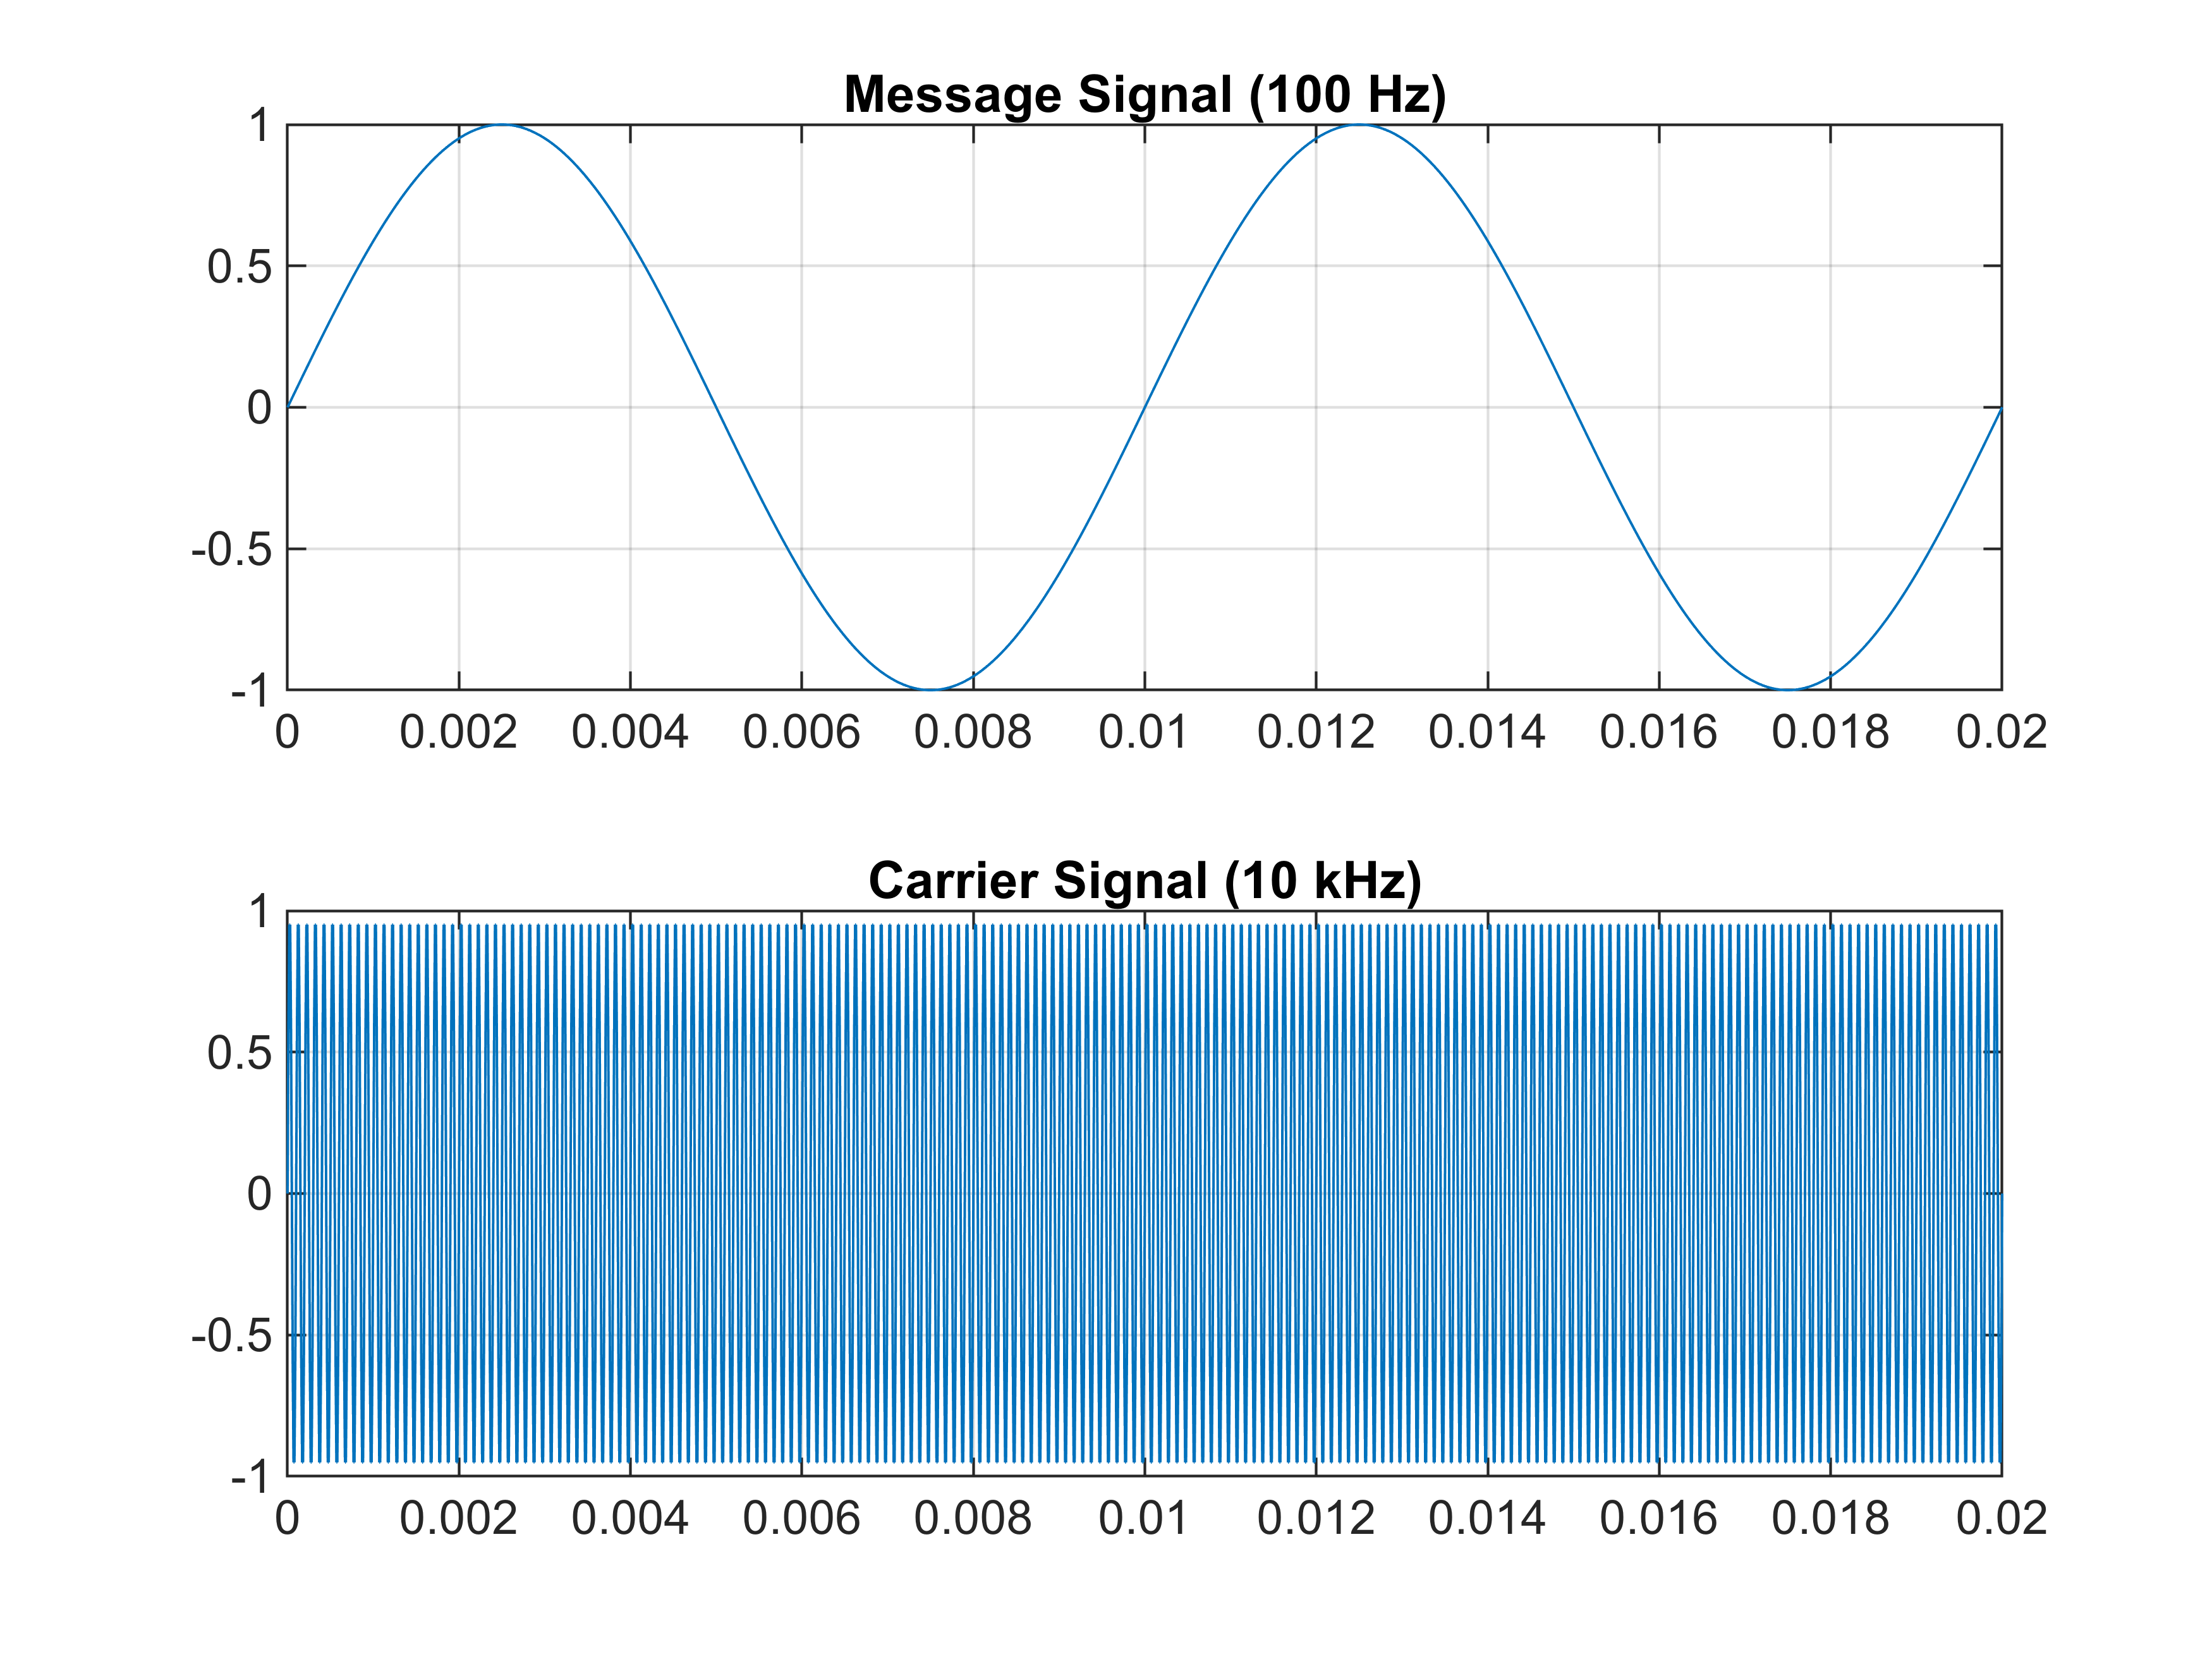

In [1]:

clc;
clear;
close all;

Fs = 100000;
t = 0:1/Fs:0.02;

m = sin(2*pi*100*t);      % message
c = sin(2*pi*10000*t);    % carrier

subplot(2,1,1)
plot(t,m)
title('Message Signal (100 Hz)')
grid on

subplot(2,1,2)
plot(t,c)
title('Carrier Signal (10 kHz)')
grid on


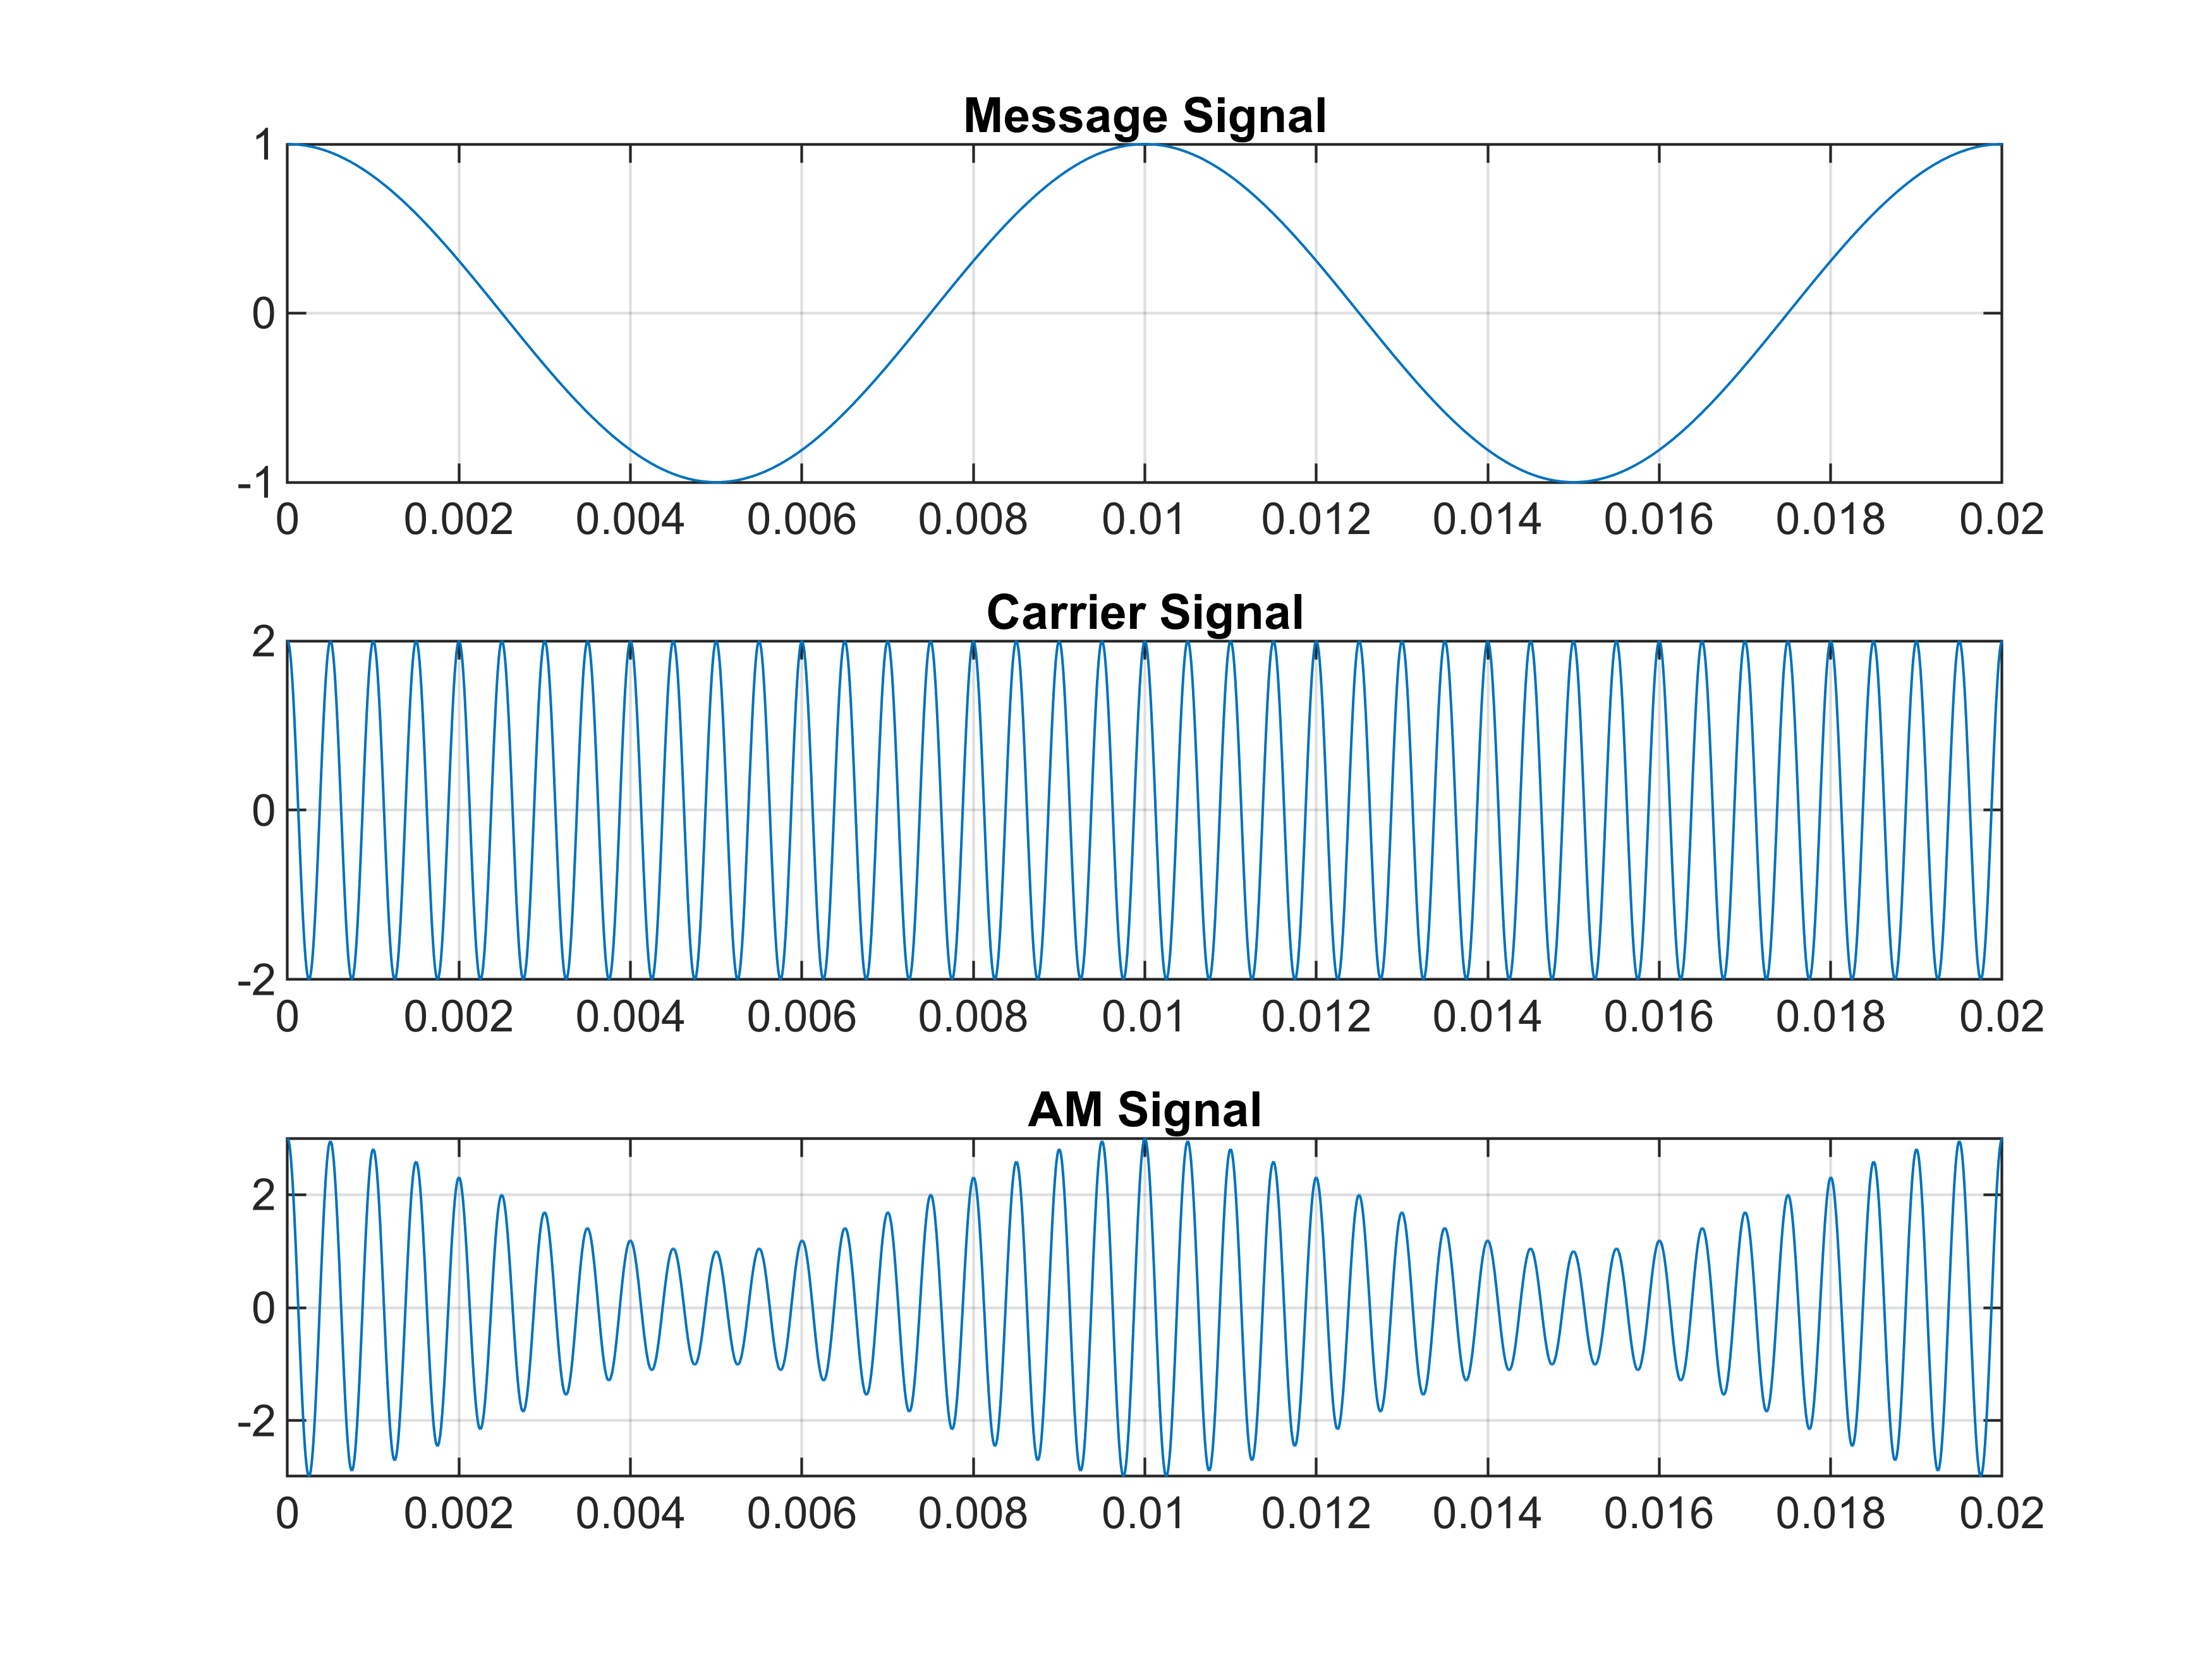

In [2]:

clc;
clear;
close all;

Fs = 100000;
t = 0:1/Fs:0.02;

Am = 1;
Ac = 2;

fm = 100;
fc = 2000;

m = Am*cos(2*pi*fm*t);
c = Ac*cos(2*pi*fc*t);

mu = Am/Ac;

s = Ac*(1 + mu*cos(2*pi*fm*t)).*cos(2*pi*fc*t);

subplot(3,1,1)
plot(t,m)
title('Message Signal')
grid on

subplot(3,1,2)
plot(t,c)
title('Carrier Signal')
grid on

subplot(3,1,3)
plot(t,s)
title('AM Signal')
grid on


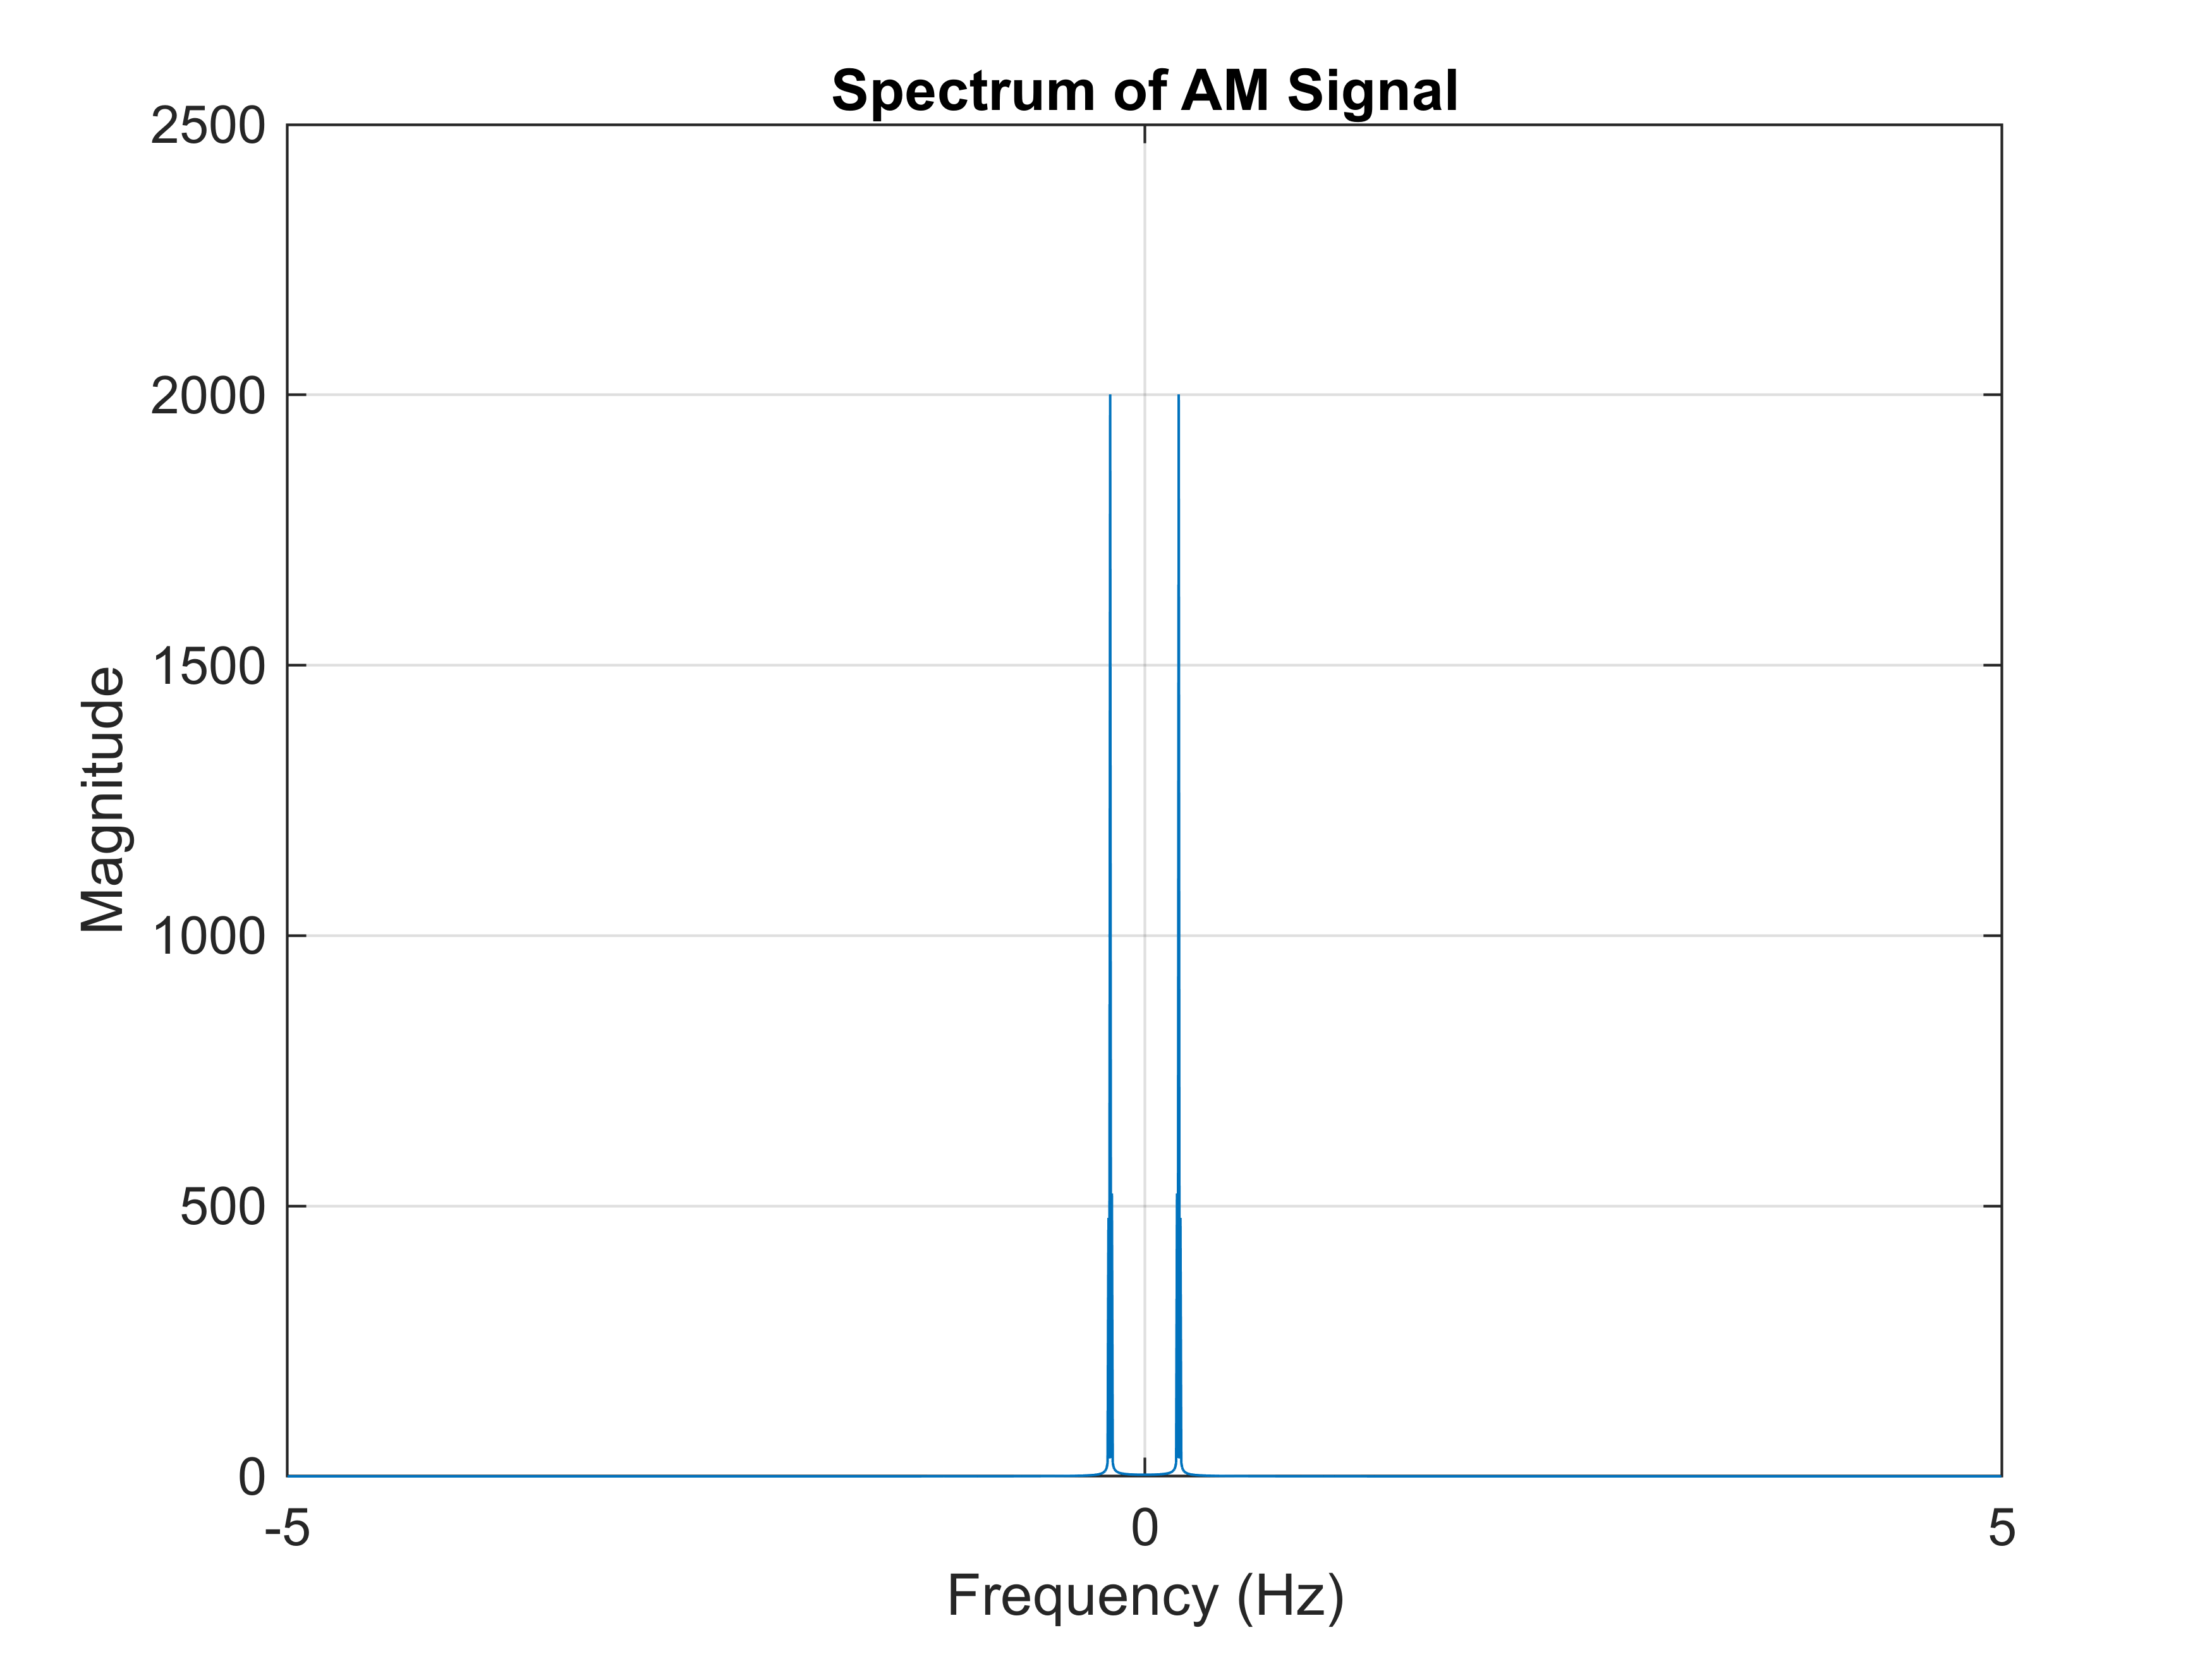

In [3]:

N = length(s);
%%
S = fftshift(abs(fft(s)));

f = (-N/2:N/2-1)*(Fs/N);

figure
plot(f,S)

xlabel('Frequency (Hz)')
ylabel('Magnitude')
title('Spectrum of AM Signal')
grid on

In [4]:

clc;
clear;
close all;
Fs = 100000;
t = 0:1/Fs:0.05;

Am = 1;
Ac = 2;

fm = 100;
fc = 2000;

mu = Am/Ac;

m = Am*cos(2*pi*fm*t);

s = Ac*(1+mu*m).*cos(2*pi*fc*t);


In [5]:
env = abs(s);

In [6]:

[b, a] = butter(6, 500/(Fs/2));
recovered = filtfilt(b, a, env);


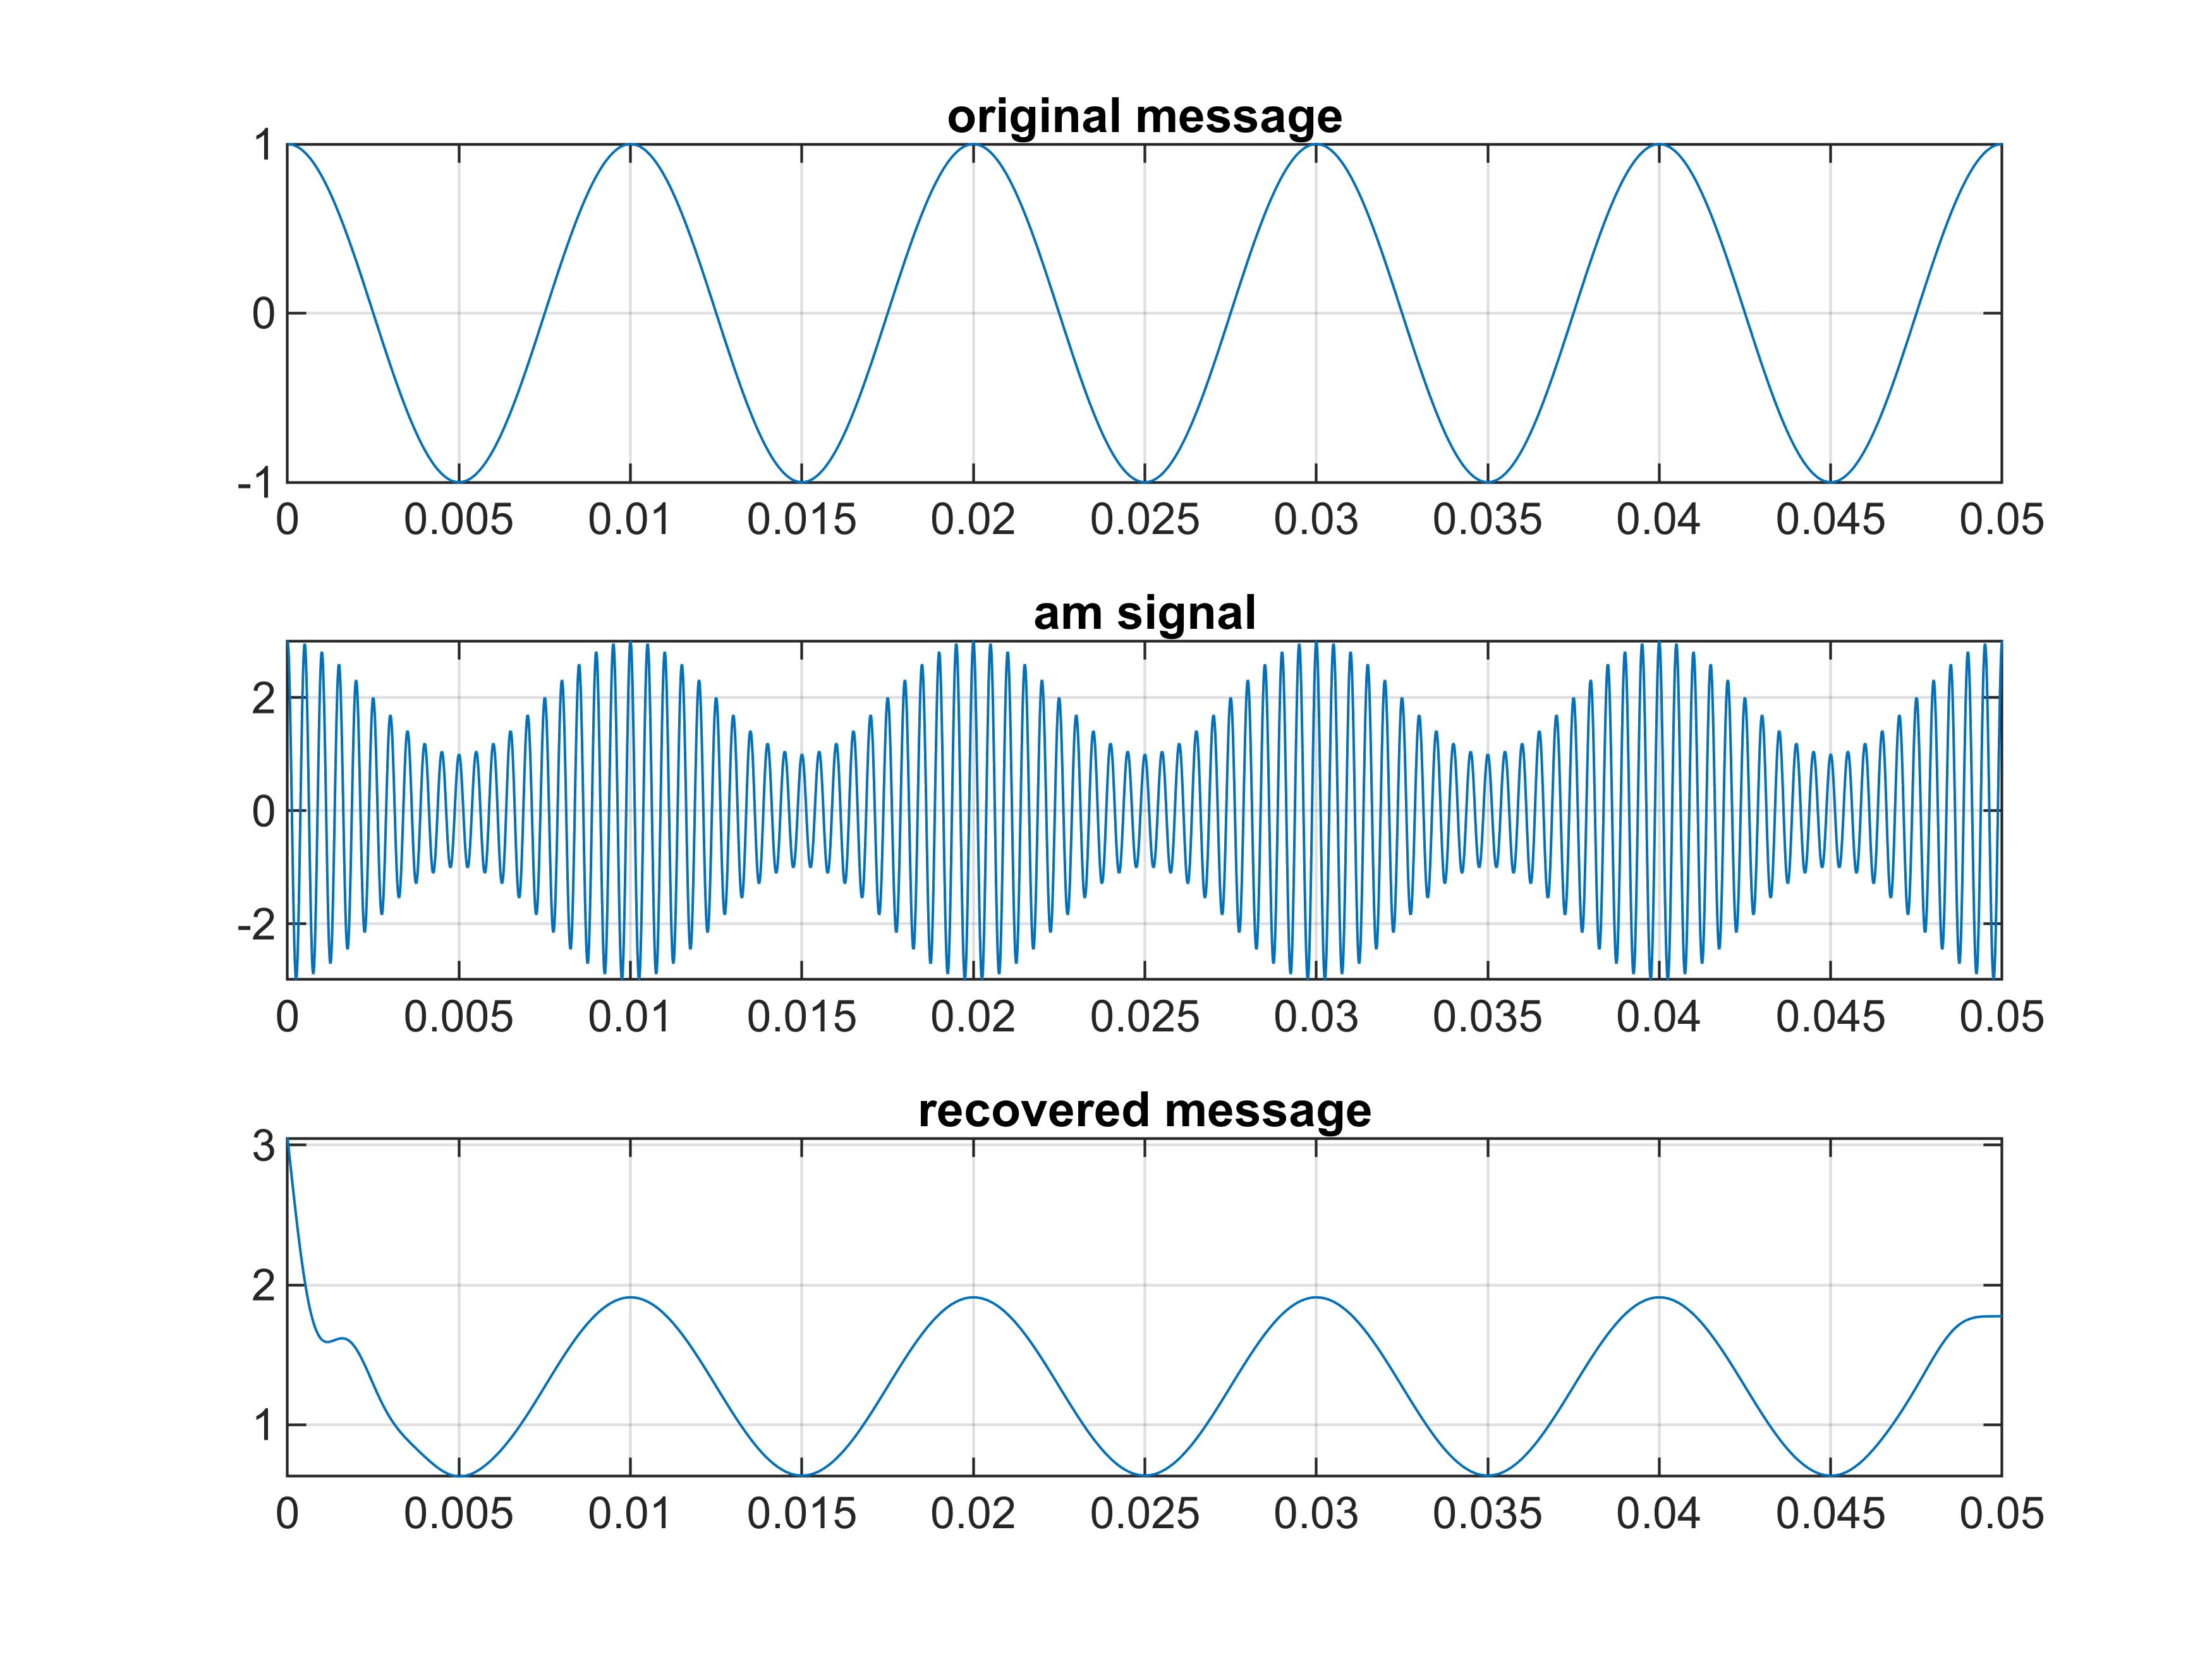

In [7]:

subplot(3, 1, 1)
plot(t, m);
title("original message");
grid on

subplot(3, 1, 2)
plot(t,s)
title("am signal")
grid on

subplot(3, 1, 3)
plot(t, recovered)
title("recovered message")
grid on


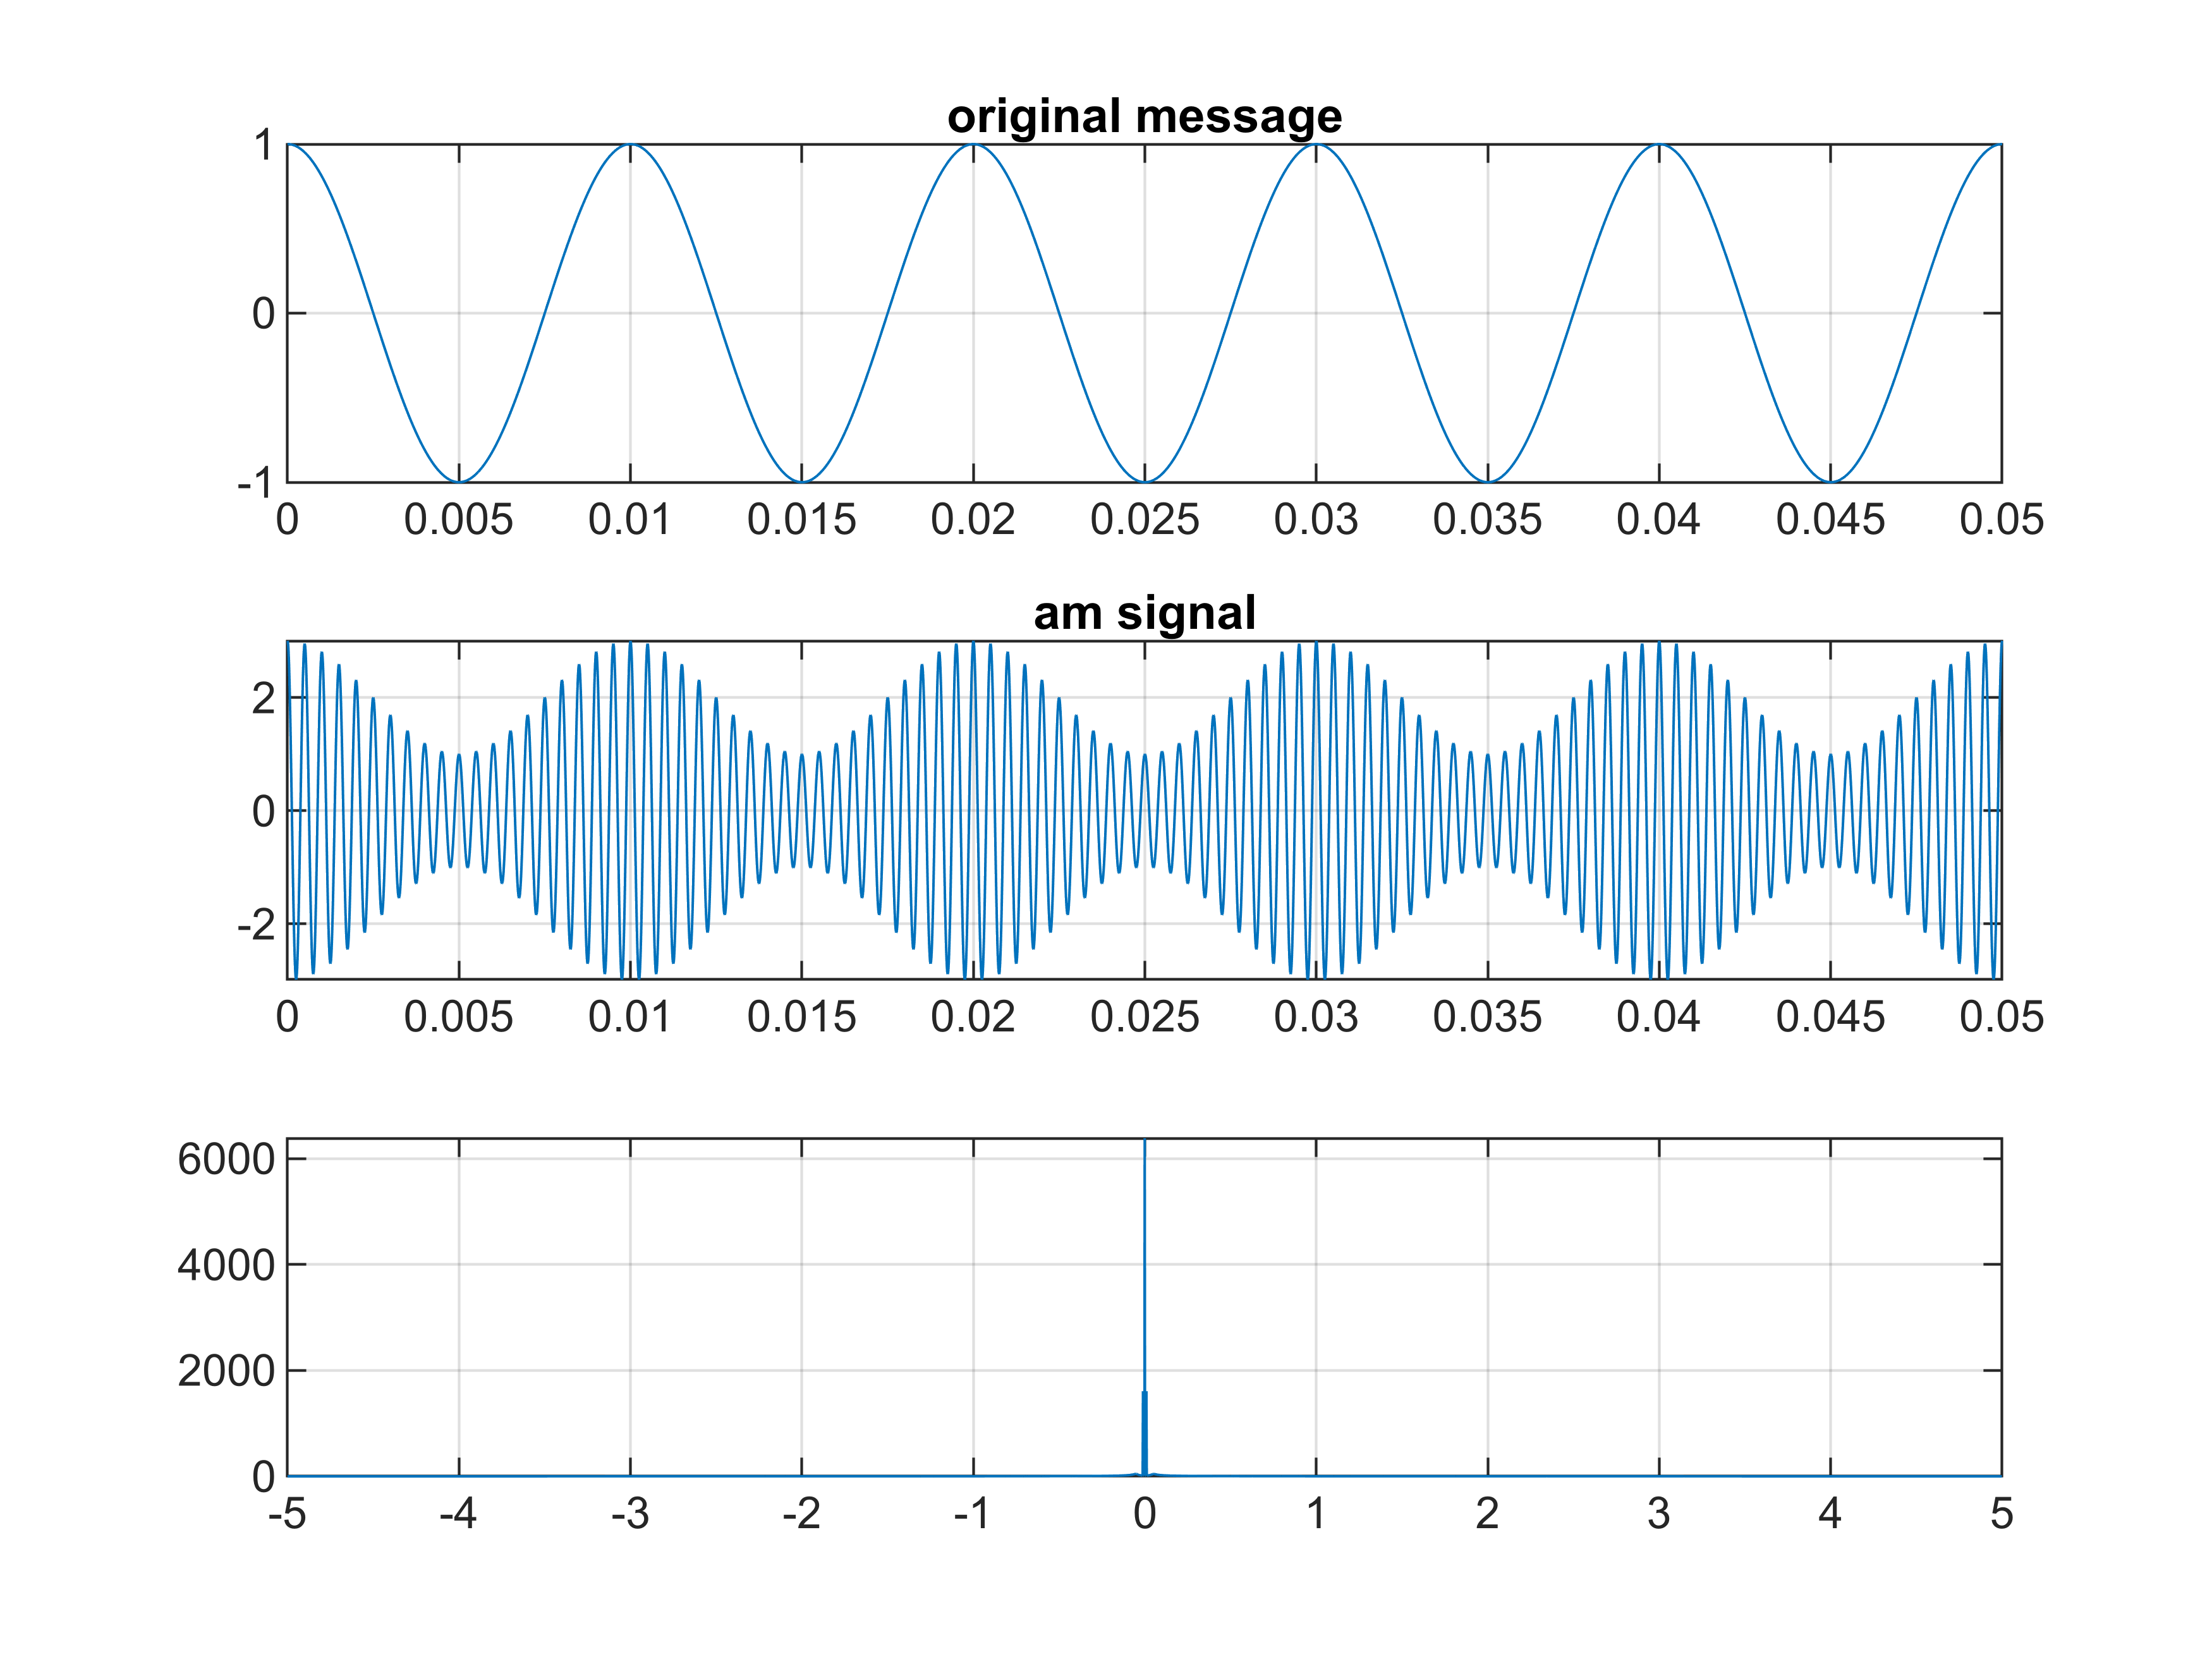

In [8]:
N = length(recovered);

X = fftshift(abs(fft(recovered)));

f = (-N/2:N/2-1)*(Fs/N);

plot(f,X)
grid on